# Day 4-7: Backtest Strategy Engine

In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
from dotenv import load_dotenv

warnings.filterwarnings('ignore')
load_dotenv('../.env')
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))

from src.data.binance_client import BinanceClient
from src.data.fng_client import FNGClient
from src.data.funding_client import FundingClient
from src.data.lunarcrush_client import LunarCrushClient
from src.signals.edi import compute_edi_v2
from src.strategy.rules import StrategyRules
from src.strategy.position_sizing import PositionSizing
from src.strategy.portfolio import PortfolioSimulator

In [2]:
# Initialize clients and strategy
binance = BinanceClient()
fng = FNGClient(cache_dir=os.path.abspath(os.path.join(os.getcwd(), '..', 'data')))
funding = FundingClient()
lunarcrush = LunarCrushClient()

strategy_rules = StrategyRules(risk_per_trade=0.02)
position_sizing = PositionSizing(risk_per_trade=0.02, max_position_size=0.10)

assets = ["BTCUSDT", "ETHUSDT", "BNBUSDT"]
days = 365

print("Fetching Market F&G Data...")
df_fng = fng.get_historical_fng(days=days)
df_fng_daily = df_fng.resample('1D').last()


Fetching Market F&G Data...


In [3]:
def backtest_asset(symbol):
    print(f"\nProcessing {symbol}...")
    df_price = binance.get_historical_ohlcv(symbol, days=days, interval="1d")
    df_funding = funding.get_funding_history(symbol, days=days)
    df_social = lunarcrush.get_historical_social(symbol.replace('USDT', ''), days=days)
    
    df_price_daily = df_price.resample('1D').last()
    df_funding_daily = df_funding.resample('1D').last()
    if not df_social.empty:
        df_social_daily = df_social.resample('1D').last()
    else:
        df_social_daily = pd.DataFrame(index=df_price_daily.index)

    df = pd.DataFrame(index=df_price_daily.index)
    df['close'] = df_price_daily['close']
    df['fng_value'] = df_fng_daily['value']
    df['fundingRate'] = df_funding_daily['fundingRate']
    df['social_sentiment'] = df_social_daily['sentiment'] if 'sentiment' in df_social_daily.columns else 50.0

    df = df.dropna(subset=['close', 'fng_value', 'fundingRate'])
    df['social_sentiment'] = df['social_sentiment'].fillna(50.0)
    
    # Compute EDI v2
    edi_scores = []
    edi_directions = []
    confidences = []
    
    for i in range(len(df)):
        if i < 14:
            edi_scores.append(0)
            edi_directions.append("no_signal")
            confidences.append(0)
            continue
            
        fng_hist = df['fng_value'].iloc[max(0, i-14):i+1]
        funding_hist = df['fundingRate'].iloc[max(0, i-7):i+1]
        price_hist = df['close'].iloc[max(0, i-14):i+1]
        
        res = compute_edi_v2(fng_hist, funding_hist, price_hist, df['social_sentiment'].iloc[i])
        edi_scores.append(res['edi_score'])
        edi_directions.append(res['direction'])
        confidences.append(res['confidence'])
        
    df['edi_score'] = edi_scores
    df['edi_direction'] = edi_directions
    df['confidence'] = confidences
    
    # Prepare inputs for PortfolioSimulator
    # simulator expects DataFrames with 'date' column
    df = df.reset_index()
    df.rename(columns={'timestamp': 'date'}, inplace=True)
    
    price_history = df[['date', 'close']]
    edi_history = df[['date', 'edi_score', 'edi_direction', 'confidence']]
    
    simulator = PortfolioSimulator(initial_capital=10000.0, strategy_rules=strategy_rules, position_sizing=position_sizing)
    report = simulator.backtest(symbol, price_history, edi_history)
    return report

reports = {}
for asset in assets:
    reports[asset] = backtest_asset(asset)



Processing BTCUSDT...


Error fetching historical LunarCrush data for bitcoin: 402 Client Error: Payment Required for url: https://lunarcrush.com/api4/public/coins/bitcoin/time-series/v2?interval=1d&limit=365



Processing ETHUSDT...


Error fetching historical LunarCrush data for ethereum: 402 Client Error: Payment Required for url: https://lunarcrush.com/api4/public/coins/ethereum/time-series/v2?interval=1d&limit=365



Processing BNBUSDT...


Error fetching historical LunarCrush data for binancecoin: 402 Client Error: Payment Required for url: https://lunarcrush.com/api4/public/coins/binancecoin/time-series/v2?interval=1d&limit=365


In [4]:
# Summary Table
summary_data = []
all_trades = []
for asset, rep in reports.items():
    summary_data.append({
        'Asset': asset,
        'Return %': f"{rep['total_return_pct']:.2f}%",
        'Sharpe Ratio': f"{rep['sharpe_ratio']:.2f}",
        'Max Drawdown %': f"{rep['max_drawdown_pct']:.2f}%",
        'Win Rate': f"{rep['win_rate']:.1%}",
        '# Trades': rep['total_trades']
    })
    for t in rep['trades']:
        t['asset'] = asset
        all_trades.append(t)

summary_df = pd.DataFrame(summary_data)
print("\n--- BACKTEST SUMMARY (10k Initial Capital) ---")
display(summary_df)

# Find best and worst trades
if all_trades:
    trades_df = pd.DataFrame(all_trades)
    best_trade = trades_df.loc[trades_df['pnl_percent'].idxmax()]
    worst_trade = trades_df.loc[trades_df['pnl_percent'].idxmin()]
    
    print("\n--- BEST TRADE ---")
    print(best_trade[['asset', 'entry_date', 'type', 'entry_price', 'exit_date', 'exit_price', 'reason', 'pnl_percent']])
    
    print("\n--- WORST TRADE ---")
    print(worst_trade[['asset', 'entry_date', 'type', 'entry_price', 'exit_date', 'exit_price', 'reason', 'pnl_percent']])
else:
    print("\nNo trades executed across any assets.")



--- BACKTEST SUMMARY (10k Initial Capital) ---


,Asset,Return %,Sharpe Ratio,Max Drawdown %,Win Rate,# Trades
0,BTCUSDT,-0.32%,0.05,-10.06%,0.0%,1
1,ETHUSDT,0.72%,0.14,-10.36%,66.7%,3
2,BNBUSDT,0.00%,0.00,0.00%,0.0%,0



--- BEST TRADE ---
asset                      ETHUSDT
entry_date     2026-03-29 00:00:00
type                          long
entry_price                1984.64
exit_date      2026-03-31 00:00:00
exit_price                 2105.43
reason          profit_target_5pct
pnl_percent               0.060862
Name: 3, dtype: object

--- WORST TRADE ---
asset                      ETHUSDT
entry_date     2026-02-10 00:00:00
type                          long
entry_price                2022.67
exit_date      2026-02-11 00:00:00
exit_price                 1941.18
reason              stop_loss_3pct
pnl_percent              -0.040288
Name: 1, dtype: object


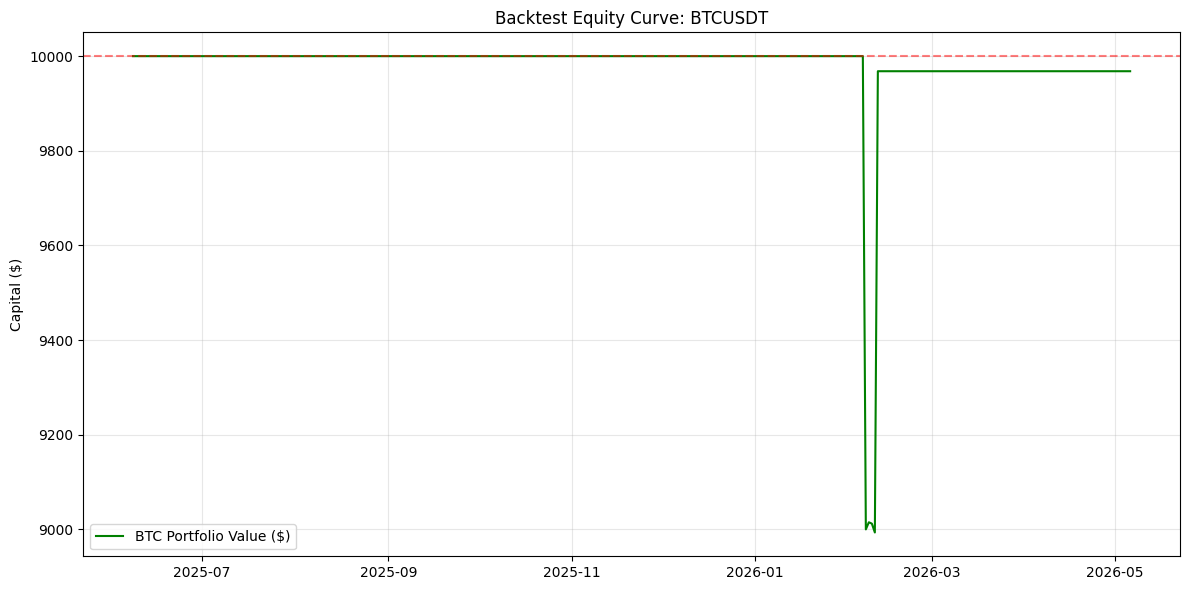

In [5]:
# Plotting Equity Curve for BTC as an example
rep_btc = reports["BTCUSDT"]
eq_df = rep_btc['equity_curve']

plt.figure(figsize=(12, 6))
plt.plot(eq_df['date'], eq_df['value'], label='BTC Portfolio Value ($)', color='green')
plt.axhline(y=10000, color='red', linestyle='--', alpha=0.5)
plt.title('Backtest Equity Curve: BTCUSDT')
plt.ylabel('Capital ($)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('btc_equity_curve.png')
plt.show()